# Appliance Energy Consumption — Regression Models

This notebook implements five regression algorithms on the **UCI Appliances Energy Prediction** dataset:

1. Decision Tree Regressor
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. Support Vector Regressor (SVR)
5. K-Nearest Neighbors Regressor (KNN)

The target variable is `Appliances`, the appliance energy consumption in Wh. UCI identifies this dataset as a multivariate, time-series **Regression** dataset with 19,735 instances and 29 columns including the target. The dataset contains no missing values. The two random variables `rv1` and `rv2` are intentionally non-predictive variables included by UCI for testing/filtering, so they are excluded from modeling.

**Important:** Because the observations are time-ordered, the held-out test set is the **last 20% chronologically**. This avoids using future observations to predict earlier ones and keeps the same test split for all five models.

Source: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

## Import Required Libraries

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

RANDOM_STATE = 42
DATA_PATH = Path("../data/energydata_complete.csv")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Model directory:", MODEL_DIR.resolve())

Model directory: C:\Users\Kartik\OneDrive\Desktop\study\CSE\Semester - 5\ML\case study\models


## Load the Dataset

In [2]:
data = pd.read_csv(DATA_PATH)

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,45.566667,17.166667,55.200000,7.026667,84.256667,17.200000,41.626667,18.200000,48.900000,17.033333,45.530000,6.600000,733.500000,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,45.992500,17.166667,55.200000,6.833333,84.063333,17.200000,41.560000,18.200000,48.863333,17.066667,45.560000,6.483333,733.600000,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,17.166667,55.090000,6.560000,83.156667,17.200000,41.433333,18.200000,48.730000,17.000000,45.500000,6.366667,733.700000,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,45.723333,17.166667,55.090000,6.433333,83.423333,17.133333,41.290000,18.100000,48.590000,17.000000,45.400000,6.250000,733.800000,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,45.530000,17.200000,55.090000,6.366667,84.893333,17.200000,41.230000,18.100000,48.590000,17.000000,45.400000,6.133333,733.900000,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097


## Explore the Dataset

In [3]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nMissing Values:")
print("Total missing values:", data.isnull().sum().sum())

print("\nDuplicate Rows:", data.duplicated().sum())

print("\nDataset Information:")
data.info()

Dataset Shape: (19735, 29)

Column Names:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']

Missing Values:
Total missing values: 0

Duplicate Rows: 0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4       

## Target Distribution

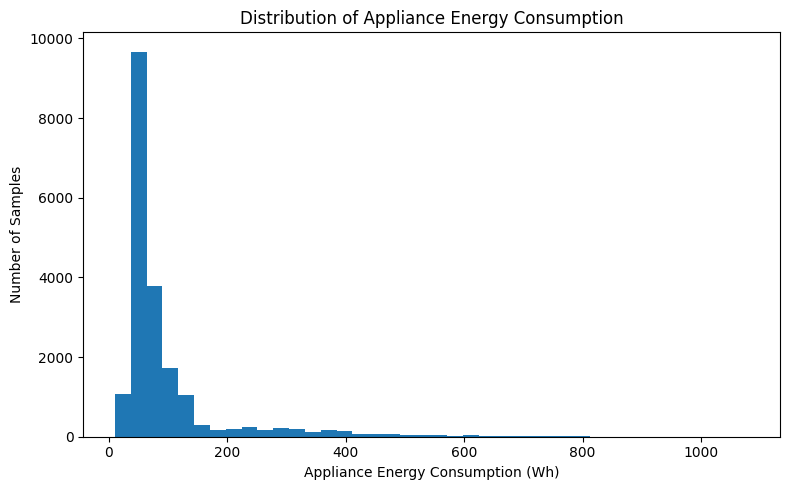

count   19735.000000
mean       97.694958
std       102.524891
min        10.000000
25%        50.000000
50%        60.000000
75%       100.000000
max      1080.000000
Name: Appliances, dtype: float64


In [4]:
plt.figure(figsize=(8, 5))
plt.hist(data["Appliances"], bins=40)
plt.xlabel("Appliance Energy Consumption (Wh)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Appliance Energy Consumption")
plt.tight_layout()
plt.show()

print(data["Appliances"].describe())

The target is a continuous numerical quantity measured in Wh, so it can be modeled directly with regression algorithms.

## Distribution of Numeric Features

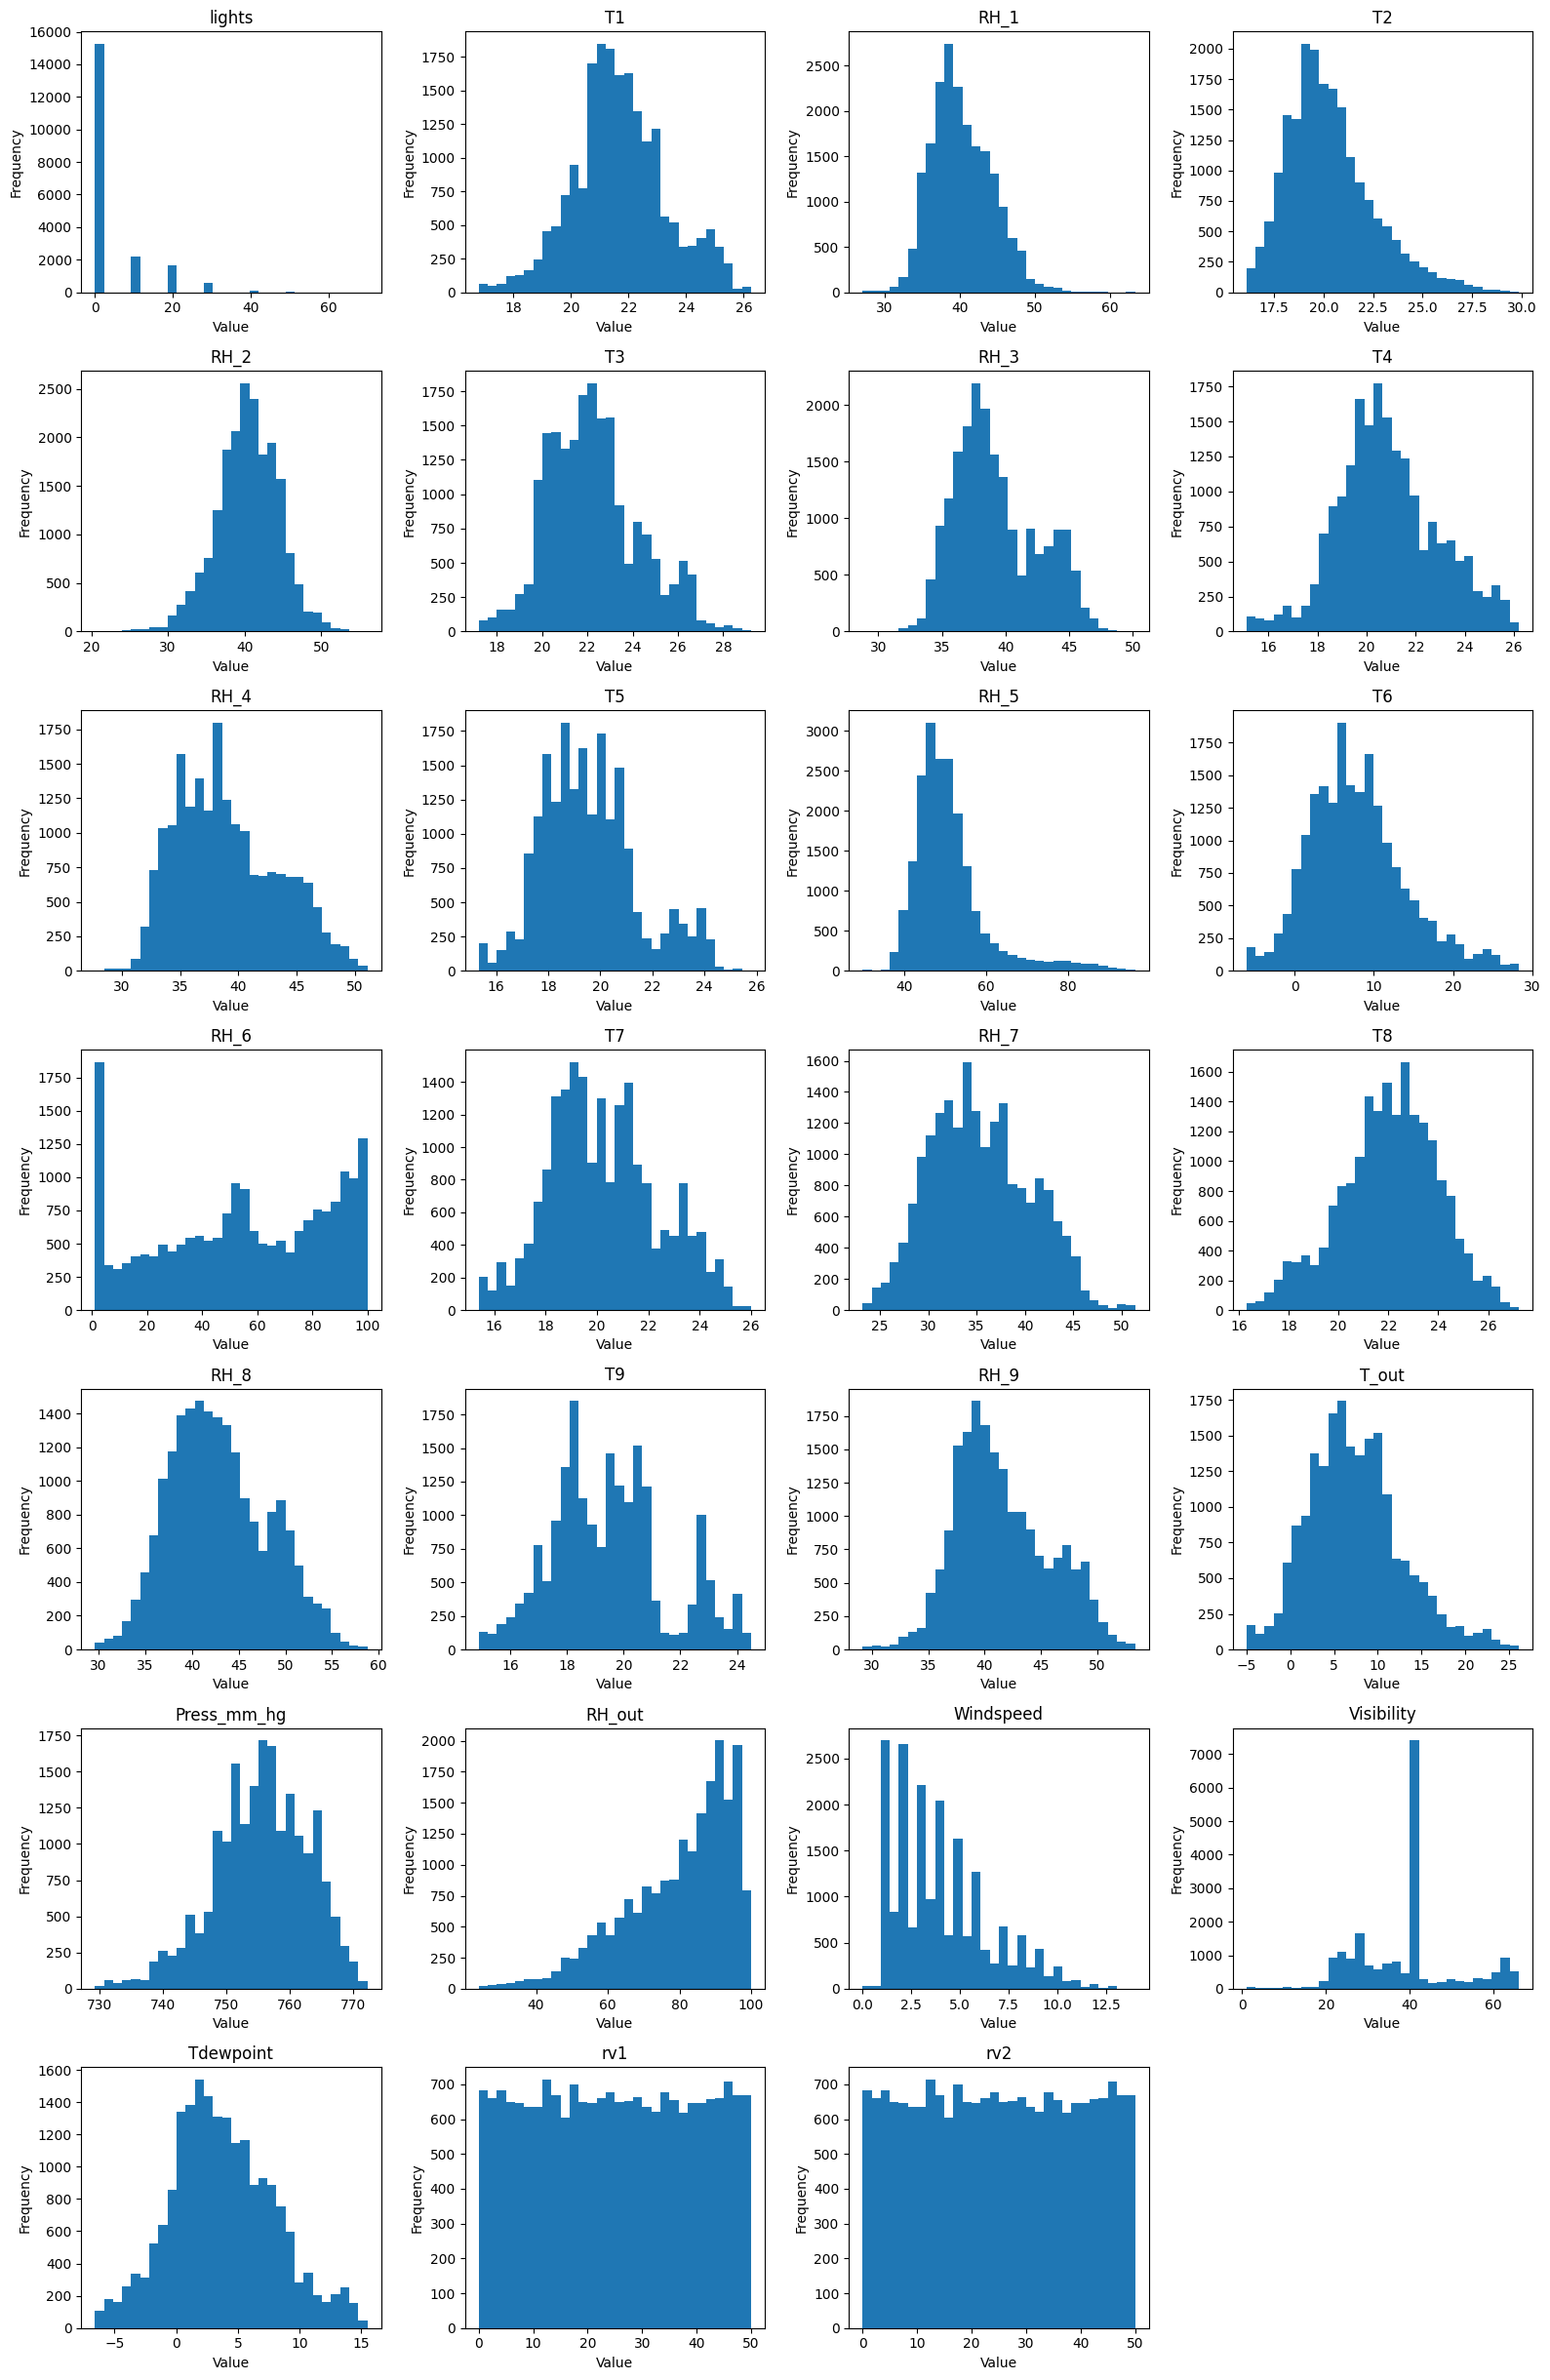

In [5]:
feature_cols_for_eda = [c for c in data.columns if c not in ["date", "Appliances"]]

n_cols = 4
n_rows = int(np.ceil(len(feature_cols_for_eda) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_cols_for_eda):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Preprocessing and Feature Engineering

The `date` column contains timestamp information. Instead of using the raw timestamp string, it is converted into time-based features that are available at prediction time. The original `date` column is then removed.

The two UCI random variables `rv1` and `rv2` are excluded because UCI states that they were included as non-predictive variables for testing/filtering.

At least one engineered feature is therefore created through the time components (`hour`, `day_of_week`, `month`, and `is_weekend`). Cyclical sine/cosine versions of hour and day-of-week are also created so distance-based models can represent the wrap-around nature of time.

In [ ]:
processed = data.copy()
processed["date"] = pd.to_datetime(processed["date"])
processed = processed.sort_values("date").reset_index(drop=True)

processed["hour"] = processed["date"].dt.hour
processed["day_of_week"] = processed["date"].dt.dayofweek
processed["month"] = processed["date"].dt.month
processed["is_weekend"] = (processed["day_of_week"] >= 5).astype(int)

processed["hour_sin"] = np.sin(2 * np.pi * processed["hour"] / 24)
processed["hour_cos"] = np.cos(2 * np.pi * processed["hour"] / 24)
processed["dow_sin"] = np.sin(2 * np.pi * processed["day_of_week"] / 7)
processed["dow_cos"] = np.cos(2 * np.pi * processed["day_of_week"] / 7)

processed = processed.drop(columns=["date", "rv1", "rv2"])

X = processed.drop(columns=["Appliances"])
y = processed["Appliances"]

print("Processed shape:", processed.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Processed shape: (19735, 34)
Features shape: (19735, 33)
Target shape: (19735,)

Features:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## Correlation Heatmap

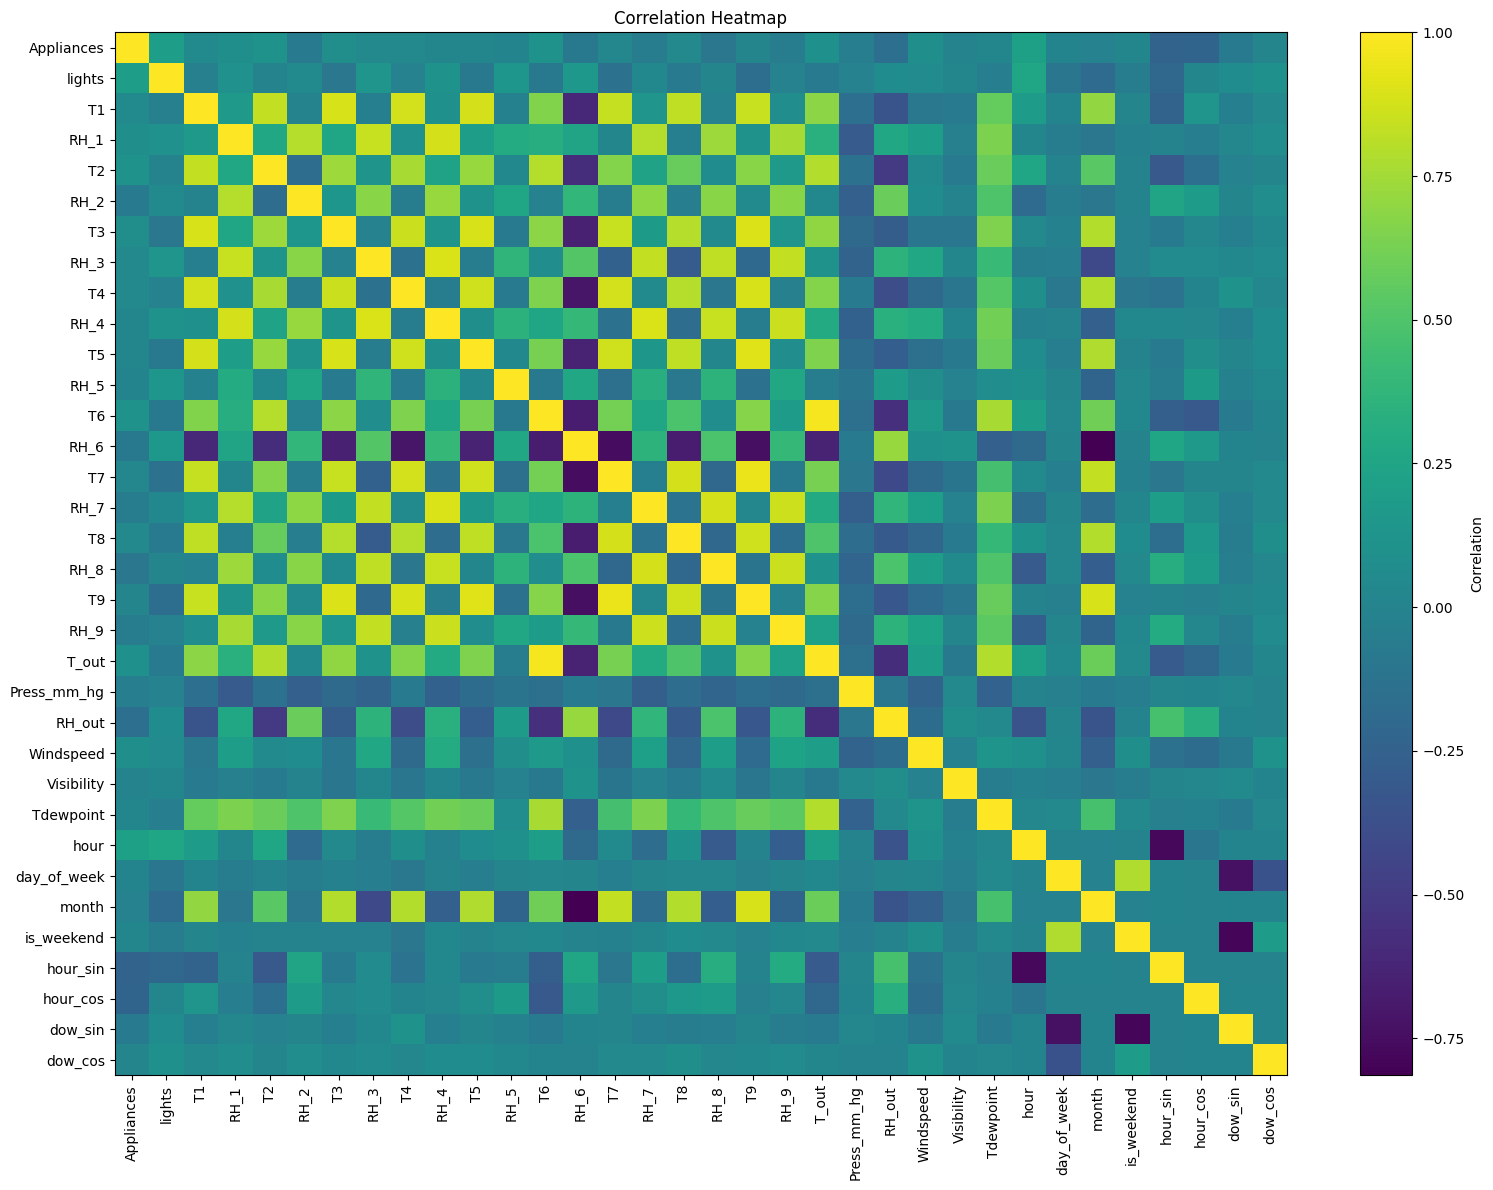

In [7]:
correlation_matrix = processed.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Feature–Target Relationships

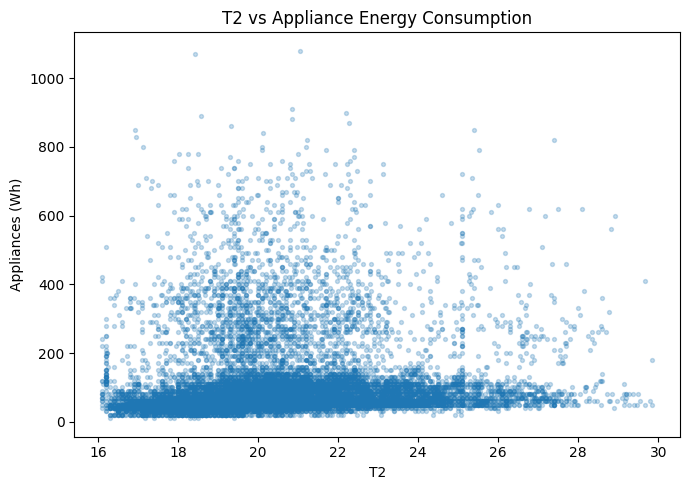

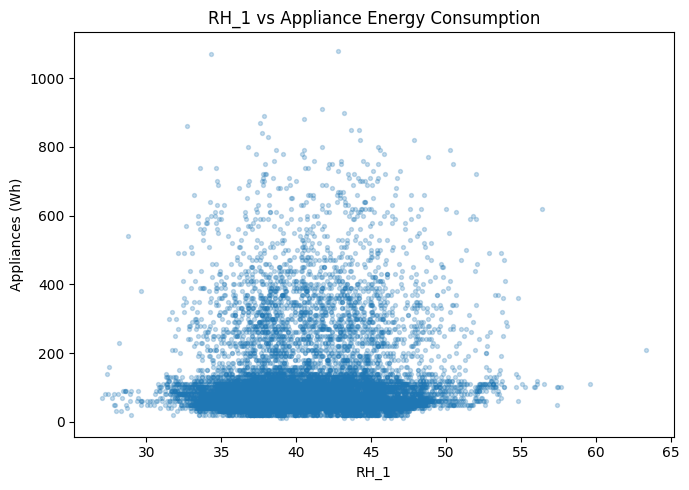

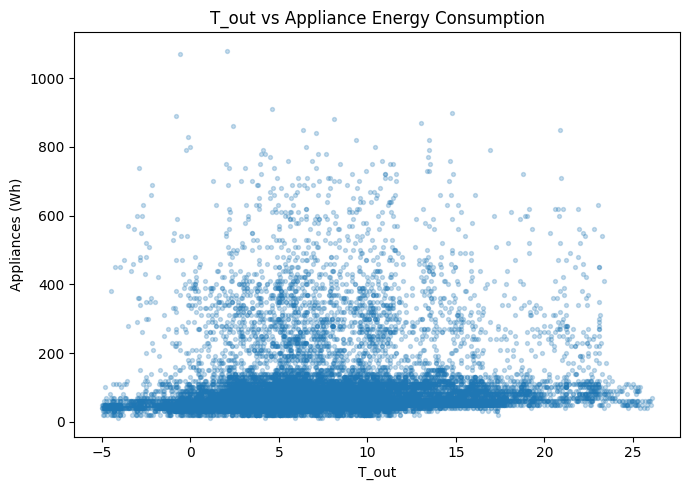

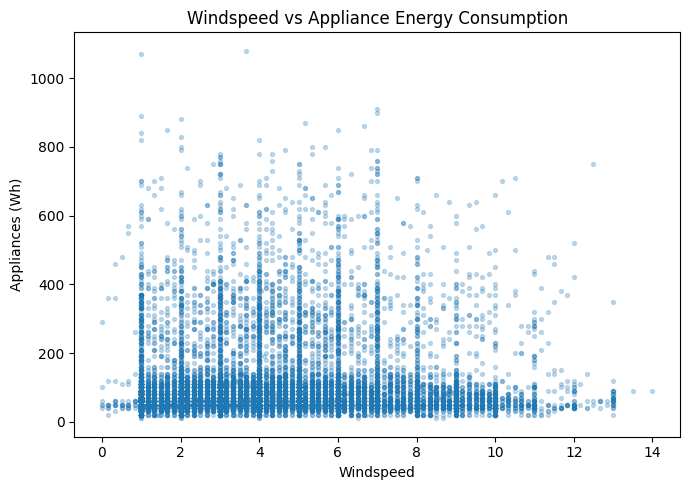

In [8]:
selected_scatter_features = ["T2", "RH_1", "T_out", "Windspeed"]

for feature in selected_scatter_features:
    plt.figure(figsize=(7, 5))
    plt.scatter(processed[feature], y, alpha=0.25, s=8)
    plt.xlabel(feature)
    plt.ylabel("Appliances (Wh)")
    plt.title(f"{feature} vs Appliance Energy Consumption")
    plt.tight_layout()
    plt.show()

## Split the Dataset

Because this is a time-series dataset, the last 20% of observations are kept as the held-out test set. All five algorithms use exactly the same chronological split. Hyperparameter searches use `TimeSeriesSplit` only on the training portion.

In [9]:
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Training period:", data["date"].min(), "to", data["date"].iloc[split_index - 1])
print("Testing period :", data["date"].iloc[split_index], "to", data["date"].max())

Training samples: 15788
Testing samples : 3947
Training period: 2016-01-11 17:00:00 to 2016-04-30 08:10:00
Testing period : 2016-04-30 08:20:00 to 2016-05-27 18:00:00


## Helper Functions

In [ ]:
def regression_metrics(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, test_pred),
        "MSE": mean_squared_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "R²": r2_score(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
    }, train_pred, test_pred


def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=4)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


tscv = TimeSeriesSplit(n_splits=3)
results = {}
best_models = {}

# 1. Decision Tree Regressor

## Initial Decision Tree Regressor

In [11]:
dt_regressor = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=3,
    random_state=RANDOM_STATE
)

dt_regressor.fit(X_train, y_train)

dt_metrics, _, dt_pred = regression_metrics(
    dt_regressor, X_train, y_train, X_test, y_test
)

print("Initial Decision Tree Regressor")
for metric, value in dt_metrics.items():
    print(f"{metric}: {value:.6f}")

Initial Decision Tree Regressor
MAE: 47.425527
MSE: 7444.575762
RMSE: 86.281955
R²: 0.101766
Train RMSE: 96.558839


## Hyperparameter Tuning — Decision Tree

`max_depth` controls model complexity. A shallow tree may underfit, while an excessively deep tree can overfit. Here the depth is selected using time-series cross-validation on the training set, rather than using the held-out test set for tuning.

In [12]:
dt_model_path = MODEL_DIR / "decision_tree.pkl"
dt_meta_path = MODEL_DIR / "decision_tree_meta.json"

dt_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, 12, 15, 20],
    "min_samples_split": [2, 3, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

if dt_model_path.exists() and dt_meta_path.exists():
    final_dt = joblib.load(dt_model_path)
    dt_meta = load_json(dt_meta_path)
    print("Loaded saved Decision Tree model.")
else:
    dt_search = GridSearchCV(
        estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
        param_grid=dt_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1
    )
    dt_search.fit(X_train, y_train)
    final_dt = dt_search.best_estimator_
    dt_meta = {
        "best_params": dt_search.best_params_,
        "best_cv_rmse": float(-dt_search.best_score_)
    }
    joblib.dump(final_dt, dt_model_path)
    save_json(dt_meta_path, dt_meta)

print("Best Parameters:")
print(dt_meta["best_params"])
print(f"Best Cross-Validation RMSE: {dt_meta['best_cv_rmse']:.6f}")

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Cross-Validation RMSE: 97.396916


## Final Decision Tree Performance

In [13]:
dt_metrics, dt_train_pred, dt_pred = regression_metrics(
    final_dt, X_train, y_train, X_test, y_test
)

print("Final Decision Tree Regressor")
for metric, value in dt_metrics.items():
    print(f"{metric}: {value:.6f}")

results["Decision Tree"] = dt_metrics
best_models["Decision Tree"] = final_dt

Final Decision Tree Regressor
MAE: 47.425527
MSE: 7444.575762
RMSE: 86.281955
R²: 0.101766
Train RMSE: 96.558839


## Decision Tree Visualization

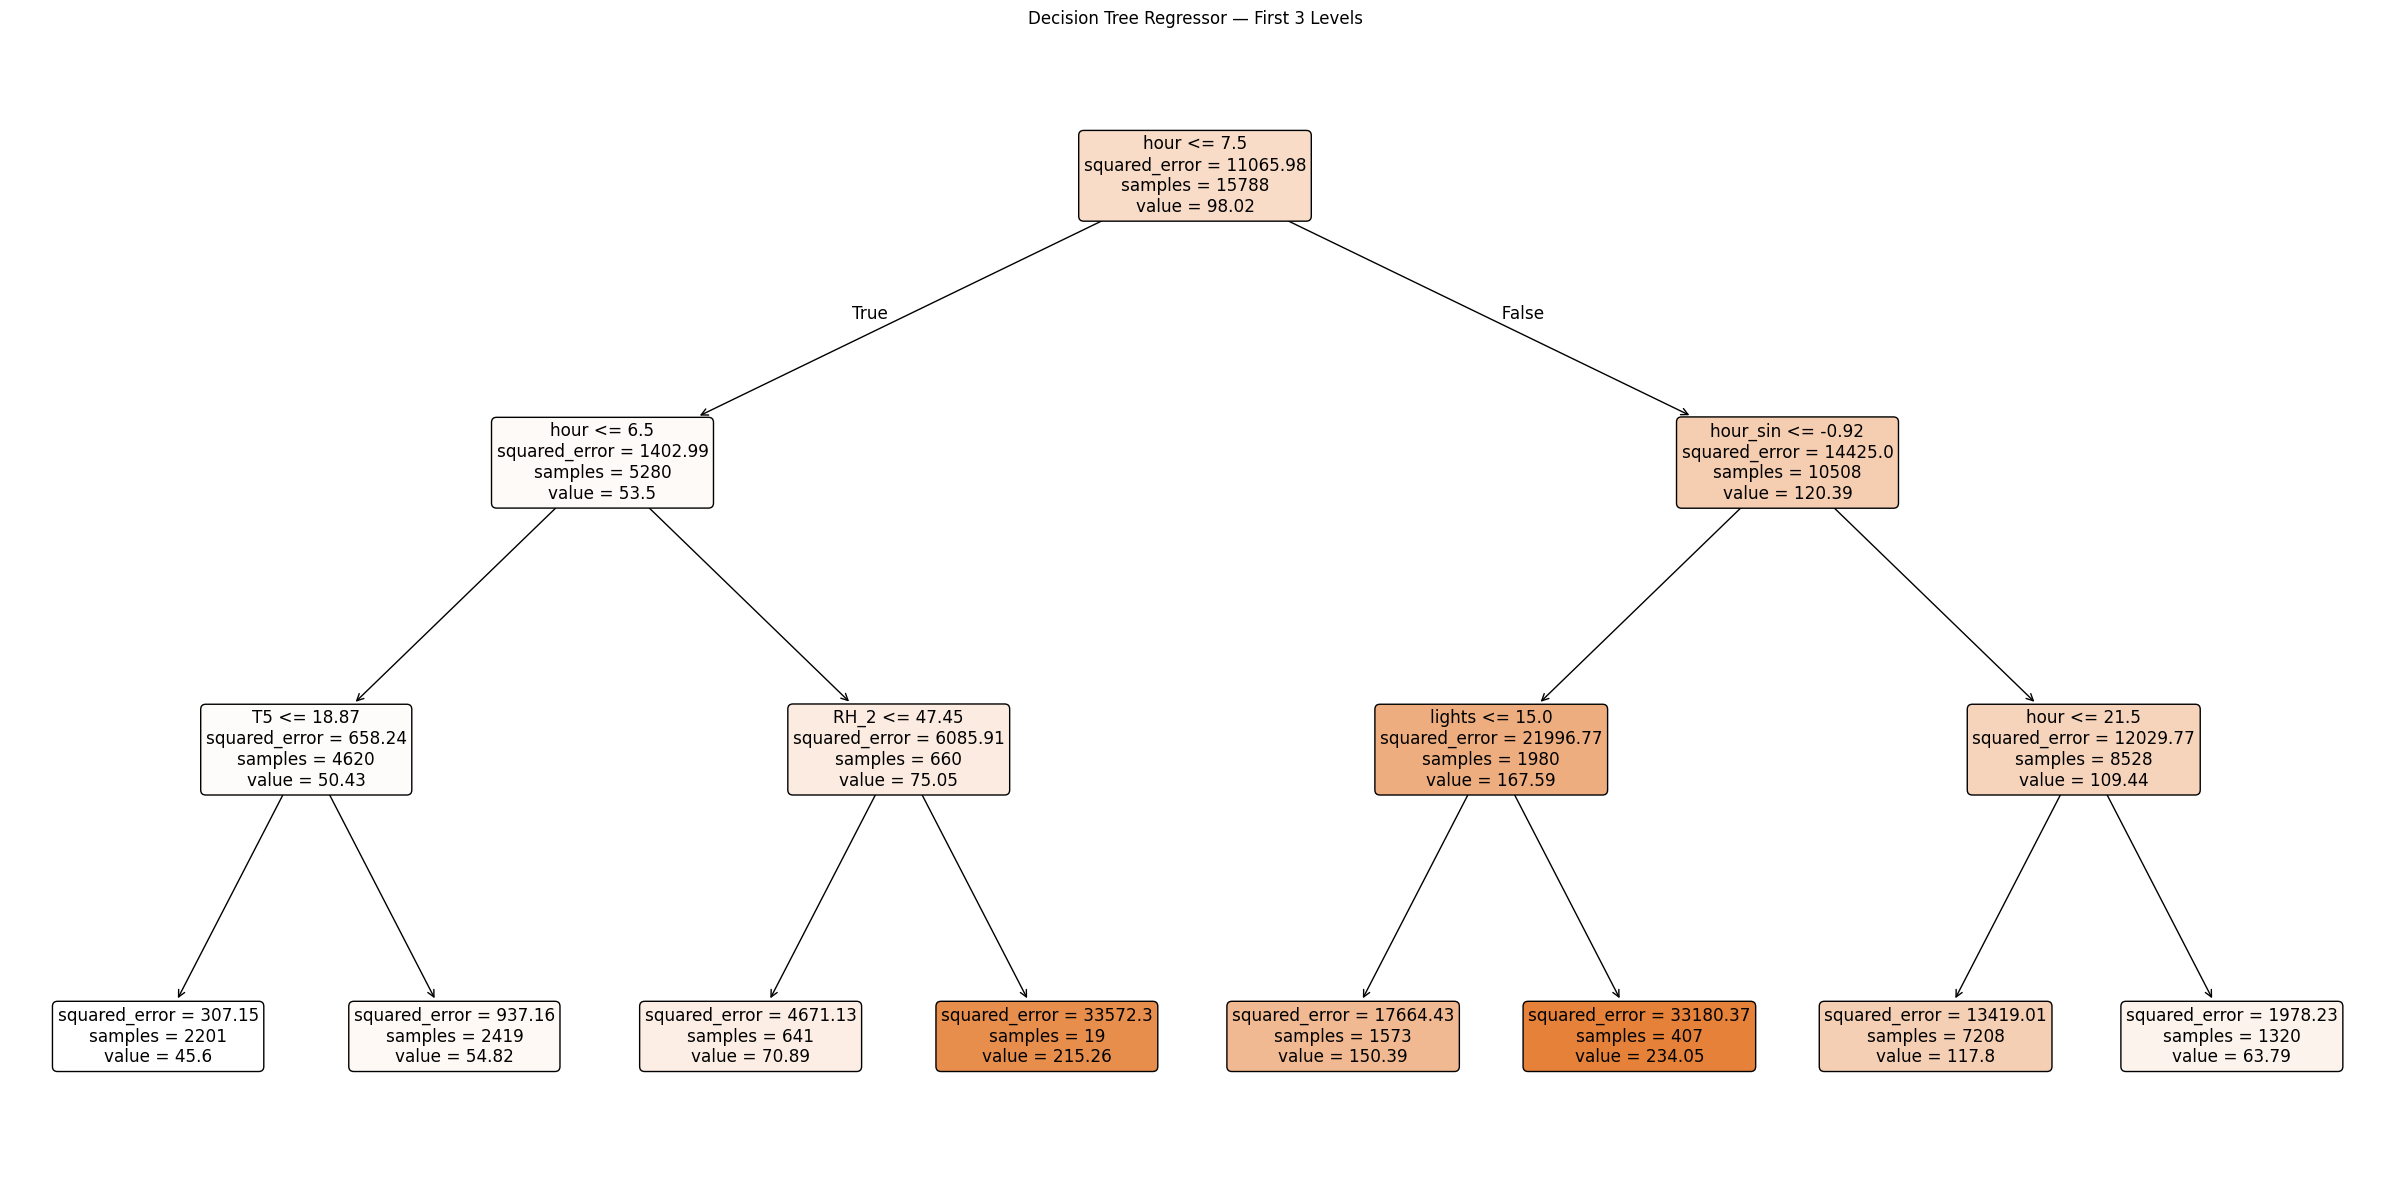

In [14]:
plt.figure(figsize=(24, 12))
plot_tree(
    final_dt,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    precision=2,
    max_depth=3
)
plt.title("Decision Tree Regressor — First 3 Levels")
plt.tight_layout()
plt.show()

# 2. Random Forest Regressor

## Initial Random Forest Regressor

In [15]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_train)
rf_metrics, _, rf_pred = regression_metrics(
    rf_regressor, X_train, y_train, X_test, y_test
)

print("Initial Random Forest Regressor")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.6f}")

Initial Random Forest Regressor
MAE: 170.762224
MSE: 43427.010968
RMSE: 208.391485
R²: -4.239737
Train RMSE: 24.424164


## Hyperparameter Tuning — Random Forest

Random Forest performance depends on interacting hyperparameters such as the number of trees, tree depth, minimum split/leaf sizes, and the number of features considered at each split. `RandomizedSearchCV` is used to search a joint space instead of changing one parameter at a time.

`neg_root_mean_squared_error` is used because scikit-learn maximizes scoring values; therefore RMSE is represented as a negative value during the search.

In [16]:
rf_model_path = MODEL_DIR / "random_forest.pkl"
rf_meta_path = MODEL_DIR / "random_forest_meta.json"

rf_param_distributions = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [5, 8, 10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [1.0, "sqrt", "log2"]
}

if rf_model_path.exists() and rf_meta_path.exists():
    final_rf = joblib.load(rf_model_path)
    rf_meta = load_json(rf_meta_path)
    print("Loaded saved Random Forest model.")
else:
    rf_search = RandomizedSearchCV(
        estimator=RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1
        ),
        param_distributions=rf_param_distributions,
        n_iter=30,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
        pre_dispatch="2*n_jobs"
    )
    rf_search.fit(X_train, y_train)
    final_rf = rf_search.best_estimator_
    rf_meta = {
        "best_params": rf_search.best_params_,
        "best_cv_rmse": float(-rf_search.best_score_)
    }
    joblib.dump(final_rf, rf_model_path)
    save_json(rf_meta_path, rf_meta)

print("Best Parameters:")
print(rf_meta["best_params"])
print(f"Best Cross-Validation RMSE: {rf_meta['best_cv_rmse']:.6f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'n_estimators': 250, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'log2', 'max_depth': 8}
Best Cross-Validation RMSE: 93.084876


## Final Random Forest Performance

In [17]:
rf_metrics, rf_train_pred, rf_pred = regression_metrics(
    final_rf, X_train, y_train, X_test, y_test
)

print("Final Random Forest Regressor")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.6f}")
print(f"RMSE Gap: {rf_metrics['RMSE'] - rf_metrics['Train RMSE']:.6f}")

results["Random Forest"] = rf_metrics
best_models["Random Forest"] = final_rf

Final Random Forest Regressor
MAE: 83.931423
MSE: 11218.663218
RMSE: 105.918191
R²: -0.353601
Train RMSE: 83.020501
RMSE Gap: 22.897690


## Random Forest Feature Importance

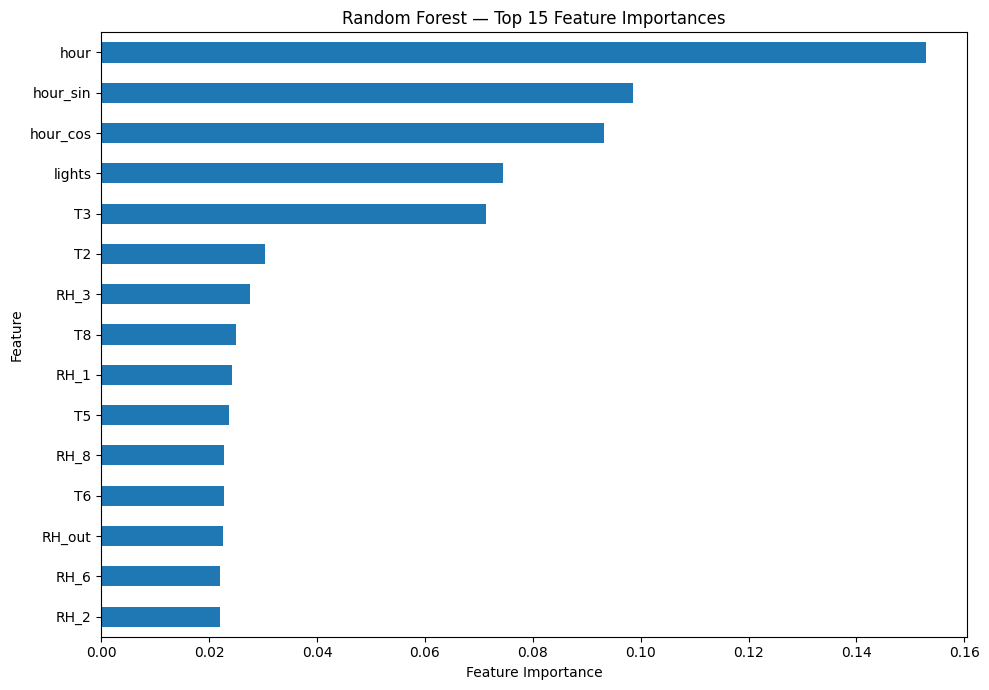

In [18]:
rf_importance = pd.Series(
    final_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
rf_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# 3. Gradient Boosting Regressor

## Initial Gradient Boosting Regressor

In [19]:
gb_regressor = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_regressor.fit(X_train, y_train)
gb_metrics, _, gb_pred = regression_metrics(
    gb_regressor, X_train, y_train, X_test, y_test
)

print("Initial Gradient Boosting Regressor")
for metric, value in gb_metrics.items():
    print(f"{metric}: {value:.6f}")

Initial Gradient Boosting Regressor
MAE: 173.436801
MSE: 47687.097983
RMSE: 218.373758
R²: -4.753742
Train RMSE: 80.949035


## Hyperparameter Tuning — Gradient Boosting

Gradient Boosting is sensitive to the interaction between `n_estimators` and `learning_rate`, as well as tree depth and minimum sample constraints. A joint randomized search is therefore used.

In [20]:
gb_model_path = MODEL_DIR / "gradient_boosting.pkl"
gb_meta_path = MODEL_DIR / "gradient_boosting_meta.json"

gb_param_distributions = {
    "n_estimators": [100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "subsample": [0.8, 1.0]
}

if gb_model_path.exists() and gb_meta_path.exists():
    final_gb = joblib.load(gb_model_path)
    gb_meta = load_json(gb_meta_path)
    print("Loaded saved Gradient Boosting model.")
else:
    gb_search = RandomizedSearchCV(
        estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
        param_distributions=gb_param_distributions,
        n_iter=25,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
        pre_dispatch="2*n_jobs"
    )
    gb_search.fit(X_train, y_train)
    final_gb = gb_search.best_estimator_
    gb_meta = {
        "best_params": gb_search.best_params_,
        "best_cv_rmse": float(-gb_search.best_score_)
    }
    joblib.dump(final_gb, gb_model_path)
    save_json(gb_meta_path, gb_meta)

print("Best Parameters:")
print(gb_meta["best_params"])
print(f"Best Cross-Validation RMSE: {gb_meta['best_cv_rmse']:.6f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 250, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 4, 'learning_rate': 0.01}
Best Cross-Validation RMSE: 95.051792


## Final Gradient Boosting Performance

In [21]:
gb_metrics, gb_train_pred, gb_pred = regression_metrics(
    final_gb, X_train, y_train, X_test, y_test
)

print("Final Gradient Boosting Regressor")
for metric, value in gb_metrics.items():
    print(f"{metric}: {value:.6f}")
print(f"RMSE Gap: {gb_metrics['RMSE'] - gb_metrics['Train RMSE']:.6f}")

results["Gradient Boosting"] = gb_metrics
best_models["Gradient Boosting"] = final_gb

Final Gradient Boosting Regressor
MAE: 103.222199
MSE: 18143.488173
RMSE: 134.697766
R²: -1.189124
Train RMSE: 86.302799
RMSE Gap: 48.394967


# 4. Support Vector Regressor (SVR)

## Initial SVR

SVR is sensitive to feature scale, so the model is wrapped in a `Pipeline` with `StandardScaler`. The scaler is fitted only on the training folds by the cross-validation process.

In [22]:
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=10, epsilon=0.1))
])

svr_pipeline.fit(X_train, y_train)
svr_metrics, _, svr_pred = regression_metrics(
    svr_pipeline, X_train, y_train, X_test, y_test
)

print("Initial SVR")
for metric, value in svr_metrics.items():
    print(f"{metric}: {value:.6f}")

Initial SVR
MAE: 43.052908
MSE: 7680.197553
RMSE: 87.636736
R²: 0.073337
Train RMSE: 94.908065


## Hyperparameter Tuning — SVR

The important SVR hyperparameters are `C`, `epsilon`, `kernel`, and (for the RBF kernel) `gamma`. Because kernelized SVR can be computationally expensive on a dataset of this size, the search is intentionally compact. The final selected pipeline is then fit on the full training set.

In [23]:
svr_model_path = MODEL_DIR / "svr.pkl"
svr_meta_path = MODEL_DIR / "svr_meta.json"

svr_param_distributions = {
    "svr__kernel": ["linear", "rbf"],
    "svr__C": [0.1, 1, 3, 10, 30, 100],
    "svr__epsilon": [0.01, 0.05, 0.1, 0.2],
    "svr__gamma": ["scale", "auto", 0.001, 0.01, 0.1]
}

if svr_model_path.exists() and svr_meta_path.exists():
    final_svr = joblib.load(svr_model_path)
    svr_meta = load_json(svr_meta_path)
    print("Loaded saved SVR model.")
else:
    svr_search = RandomizedSearchCV(
        estimator=Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR())
        ]),
        param_distributions=svr_param_distributions,
        n_iter=8,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
        pre_dispatch="2*n_jobs"
    )
    svr_search.fit(X_train, y_train)
    final_svr = svr_search.best_estimator_
    svr_meta = {
        "best_params": svr_search.best_params_,
        "best_cv_rmse": float(-svr_search.best_score_)
    }
    joblib.dump(final_svr, svr_model_path)
    save_json(svr_meta_path, svr_meta)

print("Best Parameters:")
print(svr_meta["best_params"])
print(f"Best Cross-Validation RMSE: {svr_meta['best_cv_rmse']:.6f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'svr__kernel': 'rbf', 'svr__gamma': 'auto', 'svr__epsilon': 0.05, 'svr__C': 3}
Best Cross-Validation RMSE: 100.509606


## Final SVR Performance

In [ ]:
svr_metrics, svr_train_pred, svr_pred = regression_metrics(
    final_svr, X_train, y_train, X_test, y_test
)

print("Final Support Vector Regressor")
for metric, value in svr_metrics.items():
    print(f"{metric}: {value:.6f}")
print(f"RMSE Gap: {svr_metrics['RMSE'] - svr_metrics['Train RMSE']:.6f}")

results["SVR"] = svr_metrics
best_models["SVR"] = final_svr

# 5. K-Nearest Neighbors Regressor

## Initial KNN

KNN is distance-based, so feature scaling is essential. A `StandardScaler` + `KNeighborsRegressor` pipeline is used.

In [ ]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
knn_metrics, _, knn_pred = regression_metrics(
    knn_pipeline, X_train, y_train, X_test, y_test
)

print("Initial KNN")
for metric, value in knn_metrics.items():
    print(f"{metric}: {value:.6f}")

## Hyperparameter Tuning — KNN

The number of neighbors strongly affects KNN: very small `k` can produce high variance, while larger `k` smooths predictions. `weights` and the Minkowski distance parameter `p` are also considered.

In [ ]:
knn_model_path = MODEL_DIR / "knn.pkl"
knn_meta_path = MODEL_DIR / "knn_meta.json"

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 20, 30],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

if knn_model_path.exists() and knn_meta_path.exists():
    final_knn = joblib.load(knn_model_path)
    knn_meta = load_json(knn_meta_path)
    print("Loaded saved KNN model.")
else:
    knn_search = GridSearchCV(
        estimator=Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor())
        ]),
        param_grid=knn_param_grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1
    )
    knn_search.fit(X_train, y_train)
    final_knn = knn_search.best_estimator_
    knn_meta = {
        "best_params": knn_search.best_params_,
        "best_cv_rmse": float(-knn_search.best_score_)
    }
    joblib.dump(final_knn, knn_model_path)
    save_json(knn_meta_path, knn_meta)

print("Best Parameters:")
print(knn_meta["best_params"])
print(f"Best Cross-Validation RMSE: {knn_meta['best_cv_rmse']:.6f}")

## Final KNN Performance

In [ ]:
knn_metrics, knn_train_pred, knn_pred = regression_metrics(
    final_knn, X_train, y_train, X_test, y_test
)

print("Final K-Nearest Neighbors Regressor")
for metric, value in knn_metrics.items():
    print(f"{metric}: {value:.6f}")
print(f"RMSE Gap: {knn_metrics['RMSE'] - knn_metrics['Train RMSE']:.6f}")

results["KNN"] = knn_metrics
best_models["KNN"] = final_knn

# Final Comparison of All Five Regression Models

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["R²", "RMSE", "MAE", "MSE", "Train RMSE"]]
comparison_df = comparison_df.sort_values("R²", ascending=False)

print("Regression Model Comparison")
comparison_df

## Visual Comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_df["RMSE"].plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

comparison_df["R²"].plot(kind="bar", ax=axes[1])
axes[1].set_title("R² Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Cross-Validated R² for the Two Best-Performing Models

The project requires 5-fold cross-validated R² for the two best-performing models. The same chronological training data are used, with `TimeSeriesSplit(n_splits=5)` so that validation folds respect time order.

In [ ]:
best_two_names = comparison_df.head(2).index.tolist()

cv5 = TimeSeriesSplit(n_splits=5)
cv_r2_results = {}

for model_name in best_two_names:
    model = best_models[model_name]
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv5,
        scoring="r2",
        n_jobs=-1
    )

    cv_r2_results[model_name] = {
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean CV R²": scores.mean(),
        "Std CV R²": scores.std()
    }

cv_r2_df = pd.DataFrame(cv_r2_results).T
cv_r2_df

# Best Model — Predicted vs Actual

In [ ]:
best_model_name = comparison_df.index[0]
best_model = best_models[best_model_name]
best_metrics, best_train_pred, best_test_pred = regression_metrics(
    best_model, X_train, y_train, X_test, y_test
)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_test_pred, alpha=0.3, s=10)

min_value = min(y_test.min(), best_test_pred.min())
max_value = max(y_test.max(), best_test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Appliances Energy (Wh)")
plt.ylabel("Predicted Appliances Energy (Wh)")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.tight_layout()
plt.show()

# Best Model — Residual Plot

In [ ]:
residuals = y_test - best_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(best_test_pred, residuals, alpha=0.3, s=10)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Appliances Energy (Wh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()

# Final Model Selection

In [ ]:
print(f"Best model based on test R²: {best_model_name}")
print("\nFinal metrics:")
for metric, value in best_metrics.items():
    print(f"{metric}: {value:.6f}")

# Saved Models

The final trained models are stored locally using Joblib so that the expensive training/tuning process does not need to be repeated every time the notebook is opened. The notebook automatically loads an existing model if its `.pkl` and metadata `.json` file are already present; otherwise it performs the training/search and saves the result.

In [ ]:
print("Saved model files:")
for path in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"- {path.name}")

# Conclusion

The five regression algorithms were trained and evaluated on the same preprocessed chronological train/test split. Decision Tree, Random Forest, Gradient Boosting, SVR, and KNN were compared using R², RMSE, MAE, and MSE. Hyperparameter tuning was performed using training-set time-series cross-validation, and the final models were evaluated once on the untouched held-out test set.

The best-performing model is selected from the test-set comparison, followed by predicted-vs-actual and residual analysis and 5-fold cross-validated R² for the two best models.